In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join('..')))

In [2]:
import numpy as np
import pandas as pd
from src.features import cycle
from src._xgboost import search_params_mult
from src.MultiVariateForecaster import MultiVariateForecaster
from skforecast.direct import ForecasterDirectMultiVariate
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import joblib
import xgboost as xgb
import warnings
from skforecast.exceptions import IgnoredArgumentWarning

warnings.simplefilter('ignore', category=IgnoredArgumentWarning)

C:\Users\Ivan\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
def process_data(data: pd.DataFrame):
    df = data.copy()
    df = df.asfreq('D')
    
    df['day_of_year'] = df['Дата'].dt.dayofyear
    df = cycle(df, 'Месяц', 12)
    df = cycle(df, 'day_of_year', 365)
    
    df = df.drop(columns=['Дата'])
    
    df = df.interpolate(method='akima').ffill().bfill().round(2)
    
    return df

def plot_forecast(X_train, y_true, y_pred, title="Прогноз vs Истинные значения"):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
    
    if not y_pred.index.equals(y_true.index):
        y_pred.index = y_true.index
    
    ax1.plot(y_true.index, y_true.values, label='Истинные', color='blue', linewidth=1.5)
    ax1.plot(y_pred.index, y_pred.values, label='Прогноз', color='red', linestyle='--', linewidth=1.5)
    ax1.set_xlabel('Дата')
    ax1.set_ylabel('Значение')
    ax1.set_title('Тестовый период')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.tick_params(axis='x', rotation=45)
    
    ax2.plot(X_train.index, X_train.values, 
             label='Исторические (X_train)', color='green', linewidth=1.5, alpha=0.7)
    ax2.plot(y_true.index, y_true.values, 
             label='Истинные (тест)', color='blue', linewidth=1.5)
    ax2.plot(y_pred.index, y_pred.values, 
             label='Прогноз', color='red', linestyle='--', linewidth=1.5)
    ax2.set_xlabel('Дата')
    ax2.set_ylabel('Значение')
    ax2.set_title('Полный период (история + тест)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.tick_params(axis='x', rotation=45)
    
    fig.suptitle(title, fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
def fit_best_model(df_train, best_params, target_cols, exog_cols):
    xgb_params = {
        'n_estimators': best_params['n_estimators'],
        'learning_rate': best_params['learning_rate'],
        'max_depth': best_params['max_depth'],
        'subsample': best_params['subsample'],
        'colsample_bytree': best_params['colsample_bytree'],
        'colsample_bylevel': best_params['colsample_bylevel'],
        'colsample_bynode': best_params['colsample_bynode'],
        'reg_alpha': best_params['reg_alpha'],
        'reg_lambda': best_params['reg_lambda'],
        'gamma': best_params['gamma'],
        'min_child_weight': best_params['min_child_weight'],
        'max_delta_step': best_params['max_delta_step'],
        'random_state': 42,
        'verbosity': 0,
        'n_jobs': -1
    }
    
    models = []
    col = target_cols[0]
    lags_dict = {c: None for c in target_cols}
    lags_dict[col] = best_params[f'lags_{col}']
    models.append(ForecasterDirectMultiVariate(estimator=xgb.XGBRegressor(**xgb_params),
                                                level = col,
                                                steps = 1,
                                                lags = lags_dict))
    
    for i in range(1, len(target_cols)):
        col = target_cols[i]
        neighbor_col = target_cols[i - 1]
        lags_dict = {c: None for c in target_cols}
        lags_dict[col] = best_params[f'lags_{col}']
        lags_dict[neighbor_col] = best_params[f'neighbor_lags_{col}']
        models.append(ForecasterDirectMultiVariate(estimator=xgb.XGBRegressor(**xgb_params),
                                                level = col,
                                                steps = 1,
                                                lags = lags_dict))
        
        
    forecaster = MultiVariateForecaster(models)
    forecaster.fit(df_train[target_cols], exog=df_train[exog_cols])
    
    return forecaster

In [4]:
df_train_full = pd.read_csv('../data/processed/train_raw, ZK 68, (48-1, 48-air), 27.11.20-31.12.24.csv', parse_dates=['Дата'])
df_train_full.index = df_train_full['Дата']

df_test = pd.read_csv('../data/processed/test_raw, ZK 68, (48-1, 48-air), 01.01.25-15.12.25.csv', parse_dates=['Дата'])
df_test.index = df_test['Дата']

df_train = df_train_full[:'2023-12-31'].copy()
df_val = df_train_full['2024-01-01':].copy()

In [5]:
df_train_full = process_data(df_train_full)
df_train = process_data(df_train)
df_val = process_data(df_val)
df_test = process_data(df_test)

In [6]:
model_path = f'../xgboost/models/xgb_v4'
target_cols = ['48-1 (0)', '48-1 (3)', '48-1 (5)', '48-1 (7)', '48-1 (10)']
exog_cols = ['Месяц_sin', 'Месяц_cos', 'day_of_year_sin', 'day_of_year_cos']

In [7]:
study = search_params_mult(df_train, df_val, target_cols, exog_cols=exog_cols, n_trials=10)
best_params = study.best_params
print(f'Лучшие параметры = {best_params}')
print(f'Лучший RMSE score = {study.best_value}')

[I 2026-05-17 00:56:24,824] A new study created in memory with name: no-name-78dafc96-21df-4a1c-b953-d0ff96b80f9a
[I 2026-05-17 00:56:37,380] Trial 0 finished with value: 0.6844787896212879 and parameters: {'n_estimators': 507, 'learning_rate': 0.4446713833326479, 'max_depth': 7, 'subsample': 0.8533441756925708, 'colsample_bytree': 0.8853221463031895, 'colsample_bylevel': 0.6947949800808575, 'colsample_bynode': 0.7284248872153345, 'reg_alpha': 1.2183969984513478e-05, 'reg_lambda': 0.00018712038930387233, 'gamma': 0.00026773768946164716, 'min_child_weight': 15, 'max_delta_step': 3, 'lags_48-1 (0)': 2, 'lags_48-1 (3)': 1, 'neighbor_lags_48-1 (3)': 3, 'lags_48-1 (5)': 1, 'neighbor_lags_48-1 (5)': 2, 'lags_48-1 (7)': 5, 'neighbor_lags_48-1 (7)': 1, 'lags_48-1 (10)': 5, 'neighbor_lags_48-1 (10)': 3}. Best is trial 0 with value: 0.6844787896212879.
[I 2026-05-17 00:56:51,661] Trial 1 finished with value: 0.8174715162552031 and parameters: {'n_estimators': 829, 'learning_rate': 0.001078466019

Лучшие параметры = {'n_estimators': 926, 'learning_rate': 0.01654494994205325, 'max_depth': 5, 'subsample': 0.7482879628095317, 'colsample_bytree': 0.7770306793838688, 'colsample_bylevel': 0.6855527739125071, 'colsample_bynode': 0.5398453566499563, 'reg_alpha': 6.39667652343992e-05, 'reg_lambda': 0.2591569867693253, 'gamma': 0.07322152063963433, 'min_child_weight': 2, 'max_delta_step': 4, 'lags_48-1 (0)': 1, 'lags_48-1 (3)': 3, 'neighbor_lags_48-1 (3)': 1, 'lags_48-1 (5)': 3, 'neighbor_lags_48-1 (5)': 1, 'lags_48-1 (7)': 1, 'neighbor_lags_48-1 (7)': 1, 'lags_48-1 (10)': 4, 'neighbor_lags_48-1 (10)': 3}
Лучший RMSE score = 0.3405099928622299


In [8]:
model = fit_best_model(df_train, best_params, target_cols, exog_cols)
joblib.dump(model, model_path)

['../xgboost/models/xgb_v4']

48-1 (0)
RMSE на тесте = 2.910636059802429


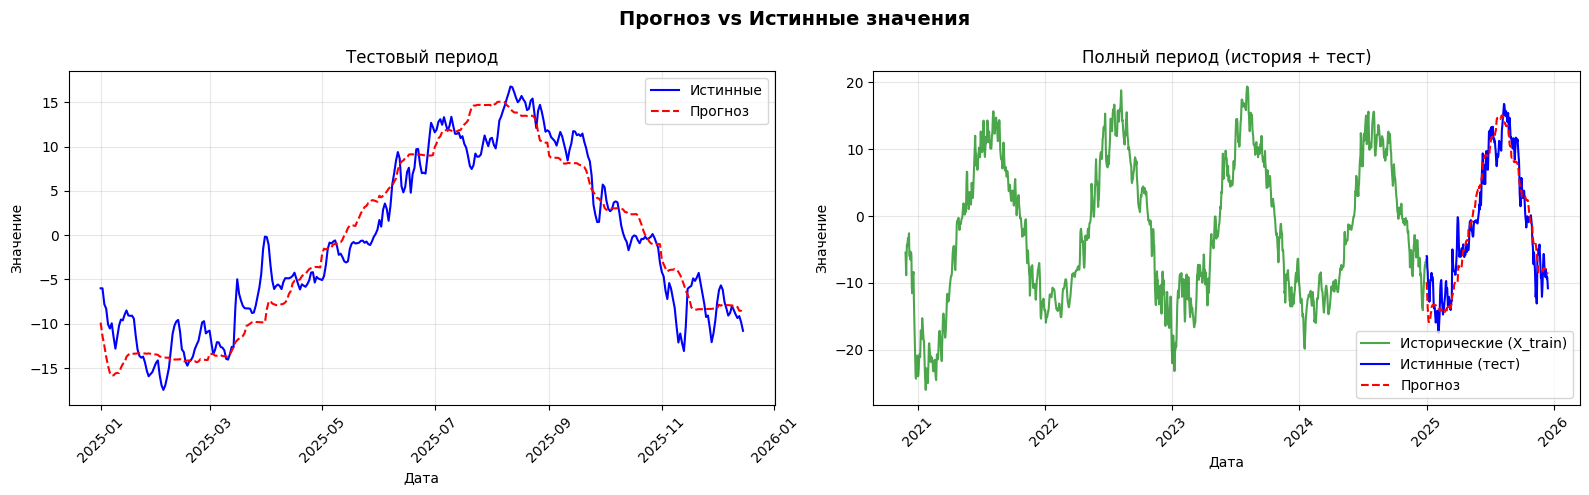

           feature  importance
2        Месяц_cos    0.413090
4  day_of_year_cos    0.225294
0   48-1 (0)_lag_1    0.170326
3  day_of_year_sin    0.097547
1        Месяц_sin    0.093743
48-1 (3)
RMSE на тесте = 0.8956073773975091


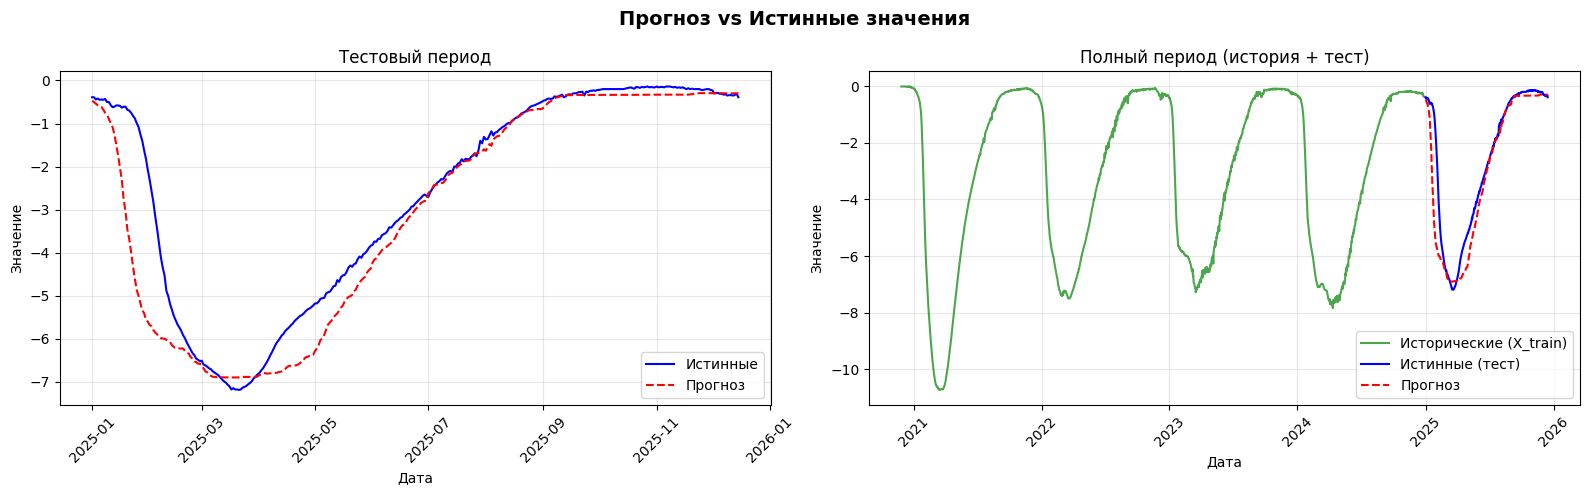

           feature  importance
4        Месяц_sin    0.380428
6  day_of_year_sin    0.154875
3   48-1 (3)_lag_3    0.142525
1   48-1 (3)_lag_1    0.125874
2   48-1 (3)_lag_2    0.122606
7  day_of_year_cos    0.033227
0   48-1 (0)_lag_1    0.020923
5        Месяц_cos    0.019543
48-1 (5)
RMSE на тесте = 0.5562094371276338


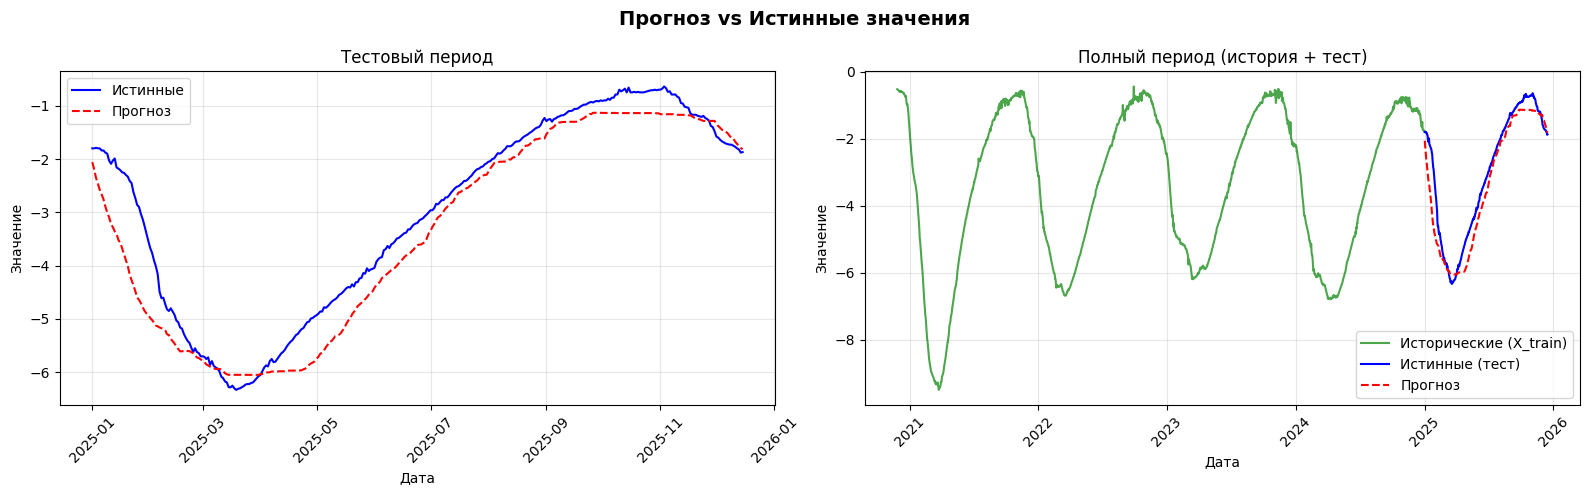

           feature  importance
4        Месяц_sin    0.263843
3   48-1 (5)_lag_3    0.161355
1   48-1 (5)_lag_1    0.158831
2   48-1 (5)_lag_2    0.146643
6  day_of_year_sin    0.124175
0   48-1 (3)_lag_1    0.110615
7  day_of_year_cos    0.020186
5        Месяц_cos    0.014352
48-1 (7)
RMSE на тесте = 0.4736342120294192


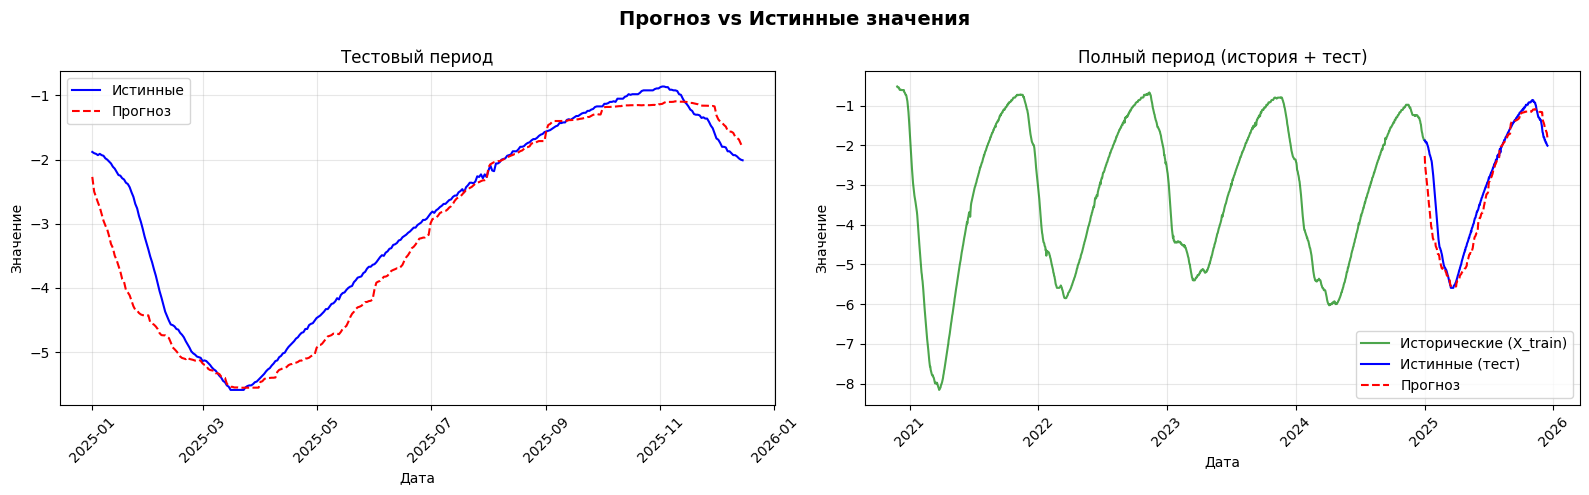

           feature  importance
2        Месяц_sin    0.355645
4  day_of_year_sin    0.189958
0   48-1 (5)_lag_1    0.186178
1   48-1 (7)_lag_1    0.179824
3        Месяц_cos    0.044509
5  day_of_year_cos    0.043886
48-1 (10)
RMSE на тесте = 0.18580702652134856


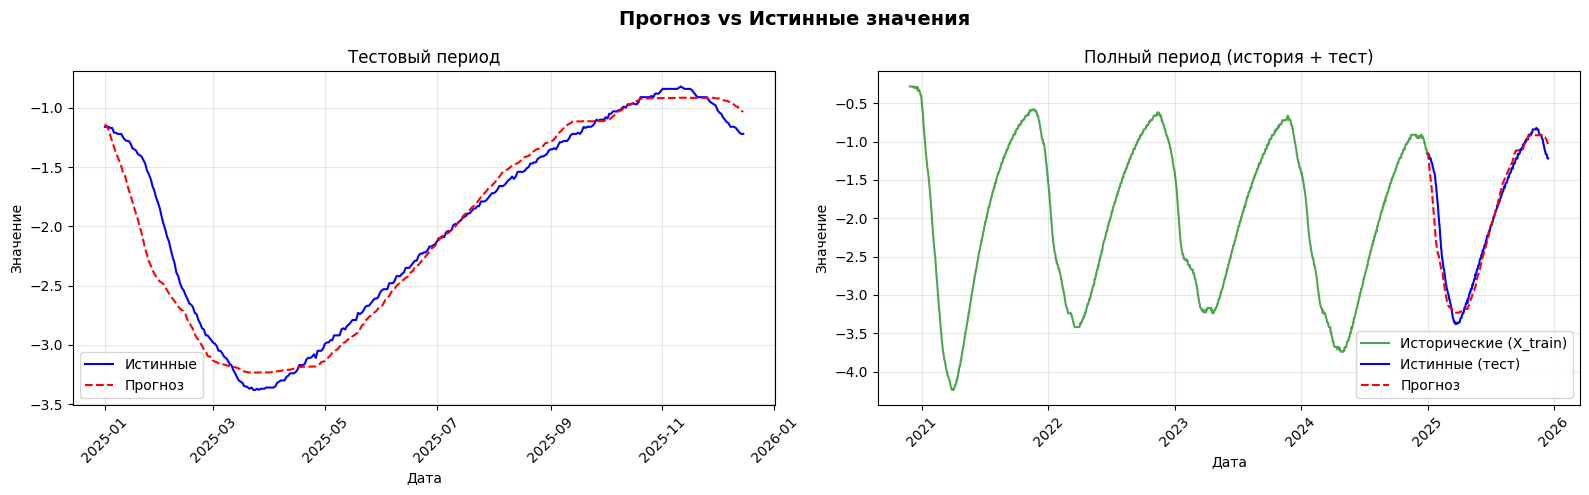

            feature  importance
7         Месяц_sin    0.243477
0    48-1 (7)_lag_1    0.158922
5   48-1 (10)_lag_3    0.097757
9   day_of_year_sin    0.090853
1    48-1 (7)_lag_2    0.090745
2    48-1 (7)_lag_3    0.089379
3   48-1 (10)_lag_1    0.075786
4   48-1 (10)_lag_2    0.062453
6   48-1 (10)_lag_4    0.043808
8         Месяц_cos    0.026746
10  day_of_year_cos    0.020075


In [9]:
model = joblib.load(model_path)
predicts = model.predict(len(df_test), df_train_full[target_cols], exog=df_test[exog_cols])
for col in target_cols:
    print(col)
    y_pred = predicts[col]
    y_true = df_test[col]
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f'RMSE на тесте = {rmse}')
    
    plot_forecast(df_train_full[col], y_true, y_pred)
    
    importances = model.forecasters[col].get_feature_importances(step = 1)
    print(importances)